# Basketball-v3 PPO Results Notebook

- 2 configs: `A_basketball_main`, `B_basketball_entropy`
- 3 train seeds: `11`, `22`, `33`
- 6M timesteps ανά run
- 4 parallel SubprocVecEnv workers
- 45/5 train-test split πάνω στις 50 MT1 task variations

In [1]:
from pathlib import Path
import ast
import pandas as pd # type: ignore
import numpy as np # type: ignore
import matplotlib.pyplot as plt # type: ignore

CSV_PATH = Path("ppo_basketball_results.csv")

# Fallback for ChatGPT sandbox / uploaded file use.
if not CSV_PATH.exists():
    candidates = list(Path("/mnt/data").glob("*basketball*results*.csv")) + list(Path("/mnt/data").glob("*.csv"))
    if candidates:
        CSV_PATH = candidates[0]

print("Using CSV:", CSV_PATH)
df = pd.read_csv(CSV_PATH)

print("Shape:", df.shape)
display(df.head())
print("Columns:")
print(df.columns.tolist())

Using CSV: ppo_basketball_results.csv
Shape: (6, 22)


,env_name,split_seed,train_seed,config_name,total_timesteps,n_parallel_envs,train_task_count,test_task_count,train_idx,test_idx,...,train_mean_return,train_std_return,test_mean_success,test_std_success,test_mean_return,test_std_return,success_gap,return_gap,tb_log_dir,model_path
0,basketball-v3,67,11,A_basketball_main,6000000,4,45,5,"[25, 35, 21, 19, 32, 48, 10, 31, 23, 34, 37, 0...","[43, 16, 20, 17, 40]",...,4446.564467,322.616973,0.6,0.489898,3811.516797,618.557284,0.355556,635.047670,tb_basketball,saved_models_basketball\ppo_basketball-v3_A_ba...
1,basketball-v3,67,22,A_basketball_main,6000000,4,45,5,"[25, 35, 21, 19, 32, 48, 10, 31, 23, 34, 37, 0...","[43, 16, 20, 17, 40]",...,4364.205456,416.707757,0.8,0.400000,4012.979498,633.640931,0.200000,351.225957,tb_basketball,saved_models_basketball\ppo_basketball-v3_A_ba...
2,basketball-v3,67,33,A_basketball_main,6000000,4,45,5,"[25, 35, 21, 19, 32, 48, 10, 31, 23, 34, 37, 0...","[43, 16, 20, 17, 40]",...,4438.329154,193.442578,1.0,0.000000,4456.540820,60.489988,-0.022222,-18.211666,tb_basketball,saved_models_basketball\ppo_basketball-v3_A_ba...
3,basketball-v3,67,11,B_basketball_entropy,6000000,4,45,5,"[25, 35, 21, 19, 32, 48, 10, 31, 23, 34, 37, 0...","[43, 16, 20, 17, 40]",...,4158.055332,767.678646,0.4,0.489898,3679.436444,584.472131,0.422222,478.618887,tb_basketball,saved_models_basketball\ppo_basketball-v3_B_ba...
4,basketball-v3,67,22,B_basketball_entropy,6000000,4,45,5,"[25, 35, 21, 19, 32, 48, 10, 31, 23, 34, 37, 0...","[43, 16, 20, 17, 40]",...,4438.200159,282.896637,0.8,0.400000,3900.009619,600.535466,0.177778,538.190540,tb_basketball,saved_models_basketball\ppo_basketball-v3_B_ba...


Columns:
['env_name', 'split_seed', 'train_seed', 'config_name', 'total_timesteps', 'n_parallel_envs', 'train_task_count', 'test_task_count', 'train_idx', 'test_idx', 'train_mean_success', 'train_std_success', 'train_mean_return', 'train_std_return', 'test_mean_success', 'test_std_success', 'test_mean_return', 'test_std_return', 'success_gap', 'return_gap', 'tb_log_dir', 'model_path']


## Experiment overview

Γρήγορη επιβεβαίωση των configs, seeds και training budget.

In [2]:
print("Environment:", df["env_name"].iloc[0] if "env_name" in df.columns else "unknown")
print("Configs:", sorted(df["config_name"].unique()))
print("Train seeds:", sorted(df["train_seed"].unique()))
print("Timesteps:", sorted(df["total_timesteps"].unique()))
print("Parallel envs:", sorted(df["n_parallel_envs"].unique()) if "n_parallel_envs" in df.columns else "unknown")
print("Rows:", len(df))

cols = [
    "config_name", "train_seed", "total_timesteps", "n_parallel_envs",
    "train_mean_success", "test_mean_success", "success_gap",
    "train_mean_return", "test_mean_return", "return_gap",
]
display(df[[c for c in cols if c in df.columns]].sort_values(["config_name", "train_seed"]))

Environment: basketball-v3
Configs: ['A_basketball_main', 'B_basketball_entropy']
Train seeds: [np.int64(11), np.int64(22), np.int64(33)]
Timesteps: [np.int64(6000000)]
Parallel envs: [np.int64(4)]
Rows: 6


,config_name,train_seed,total_timesteps,n_parallel_envs,train_mean_success,test_mean_success,success_gap,train_mean_return,test_mean_return,return_gap
0,A_basketball_main,11,6000000,4,0.955556,0.6,0.355556,4446.564467,3811.516797,635.047670
1,A_basketball_main,22,6000000,4,1.000000,0.8,0.200000,4364.205456,4012.979498,351.225957
2,A_basketball_main,33,6000000,4,0.977778,1.0,-0.022222,4438.329154,4456.540820,-18.211666
3,B_basketball_entropy,11,6000000,4,0.822222,0.4,0.422222,4158.055332,3679.436444,478.618887
4,B_basketball_entropy,22,6000000,4,0.977778,0.8,0.177778,4438.200159,3900.009619,538.190540
5,B_basketball_entropy,33,6000000,4,1.000000,1.0,0.000000,4494.502464,4501.425879,-6.923415


## 2. Train vs test success per run

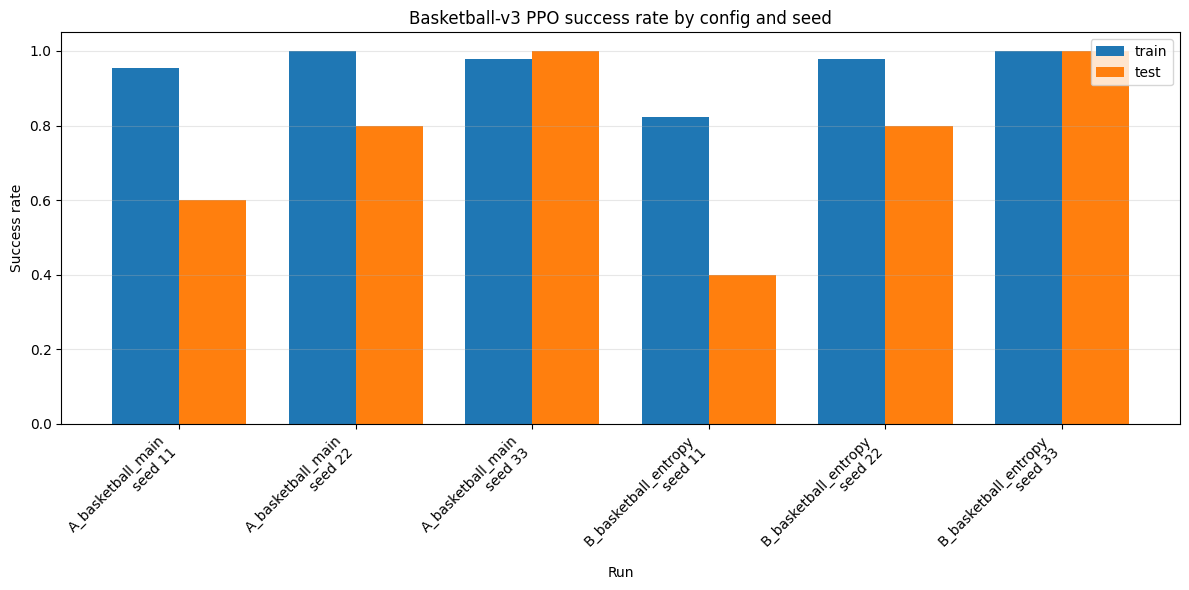

In [3]:
plot_df = df.sort_values(["config_name", "train_seed"]).reset_index(drop=True)
labels = plot_df["config_name"] + "\nseed " + plot_df["train_seed"].astype(str)
x = np.arange(len(plot_df))
width = 0.38

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, plot_df["train_mean_success"], width, label="train")
ax.bar(x + width/2, plot_df["test_mean_success"], width, label="test")
ax.set_title("Basketball-v3 PPO success rate by config and seed")
ax.set_xlabel("Run")
ax.set_ylabel("Success rate")
ax.set_ylim(0, 1.05)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.grid(True, axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 3. Success rate by seed

Εδώ φαίνεται καθαρά το seed sensitivity του `basketball-v3`.

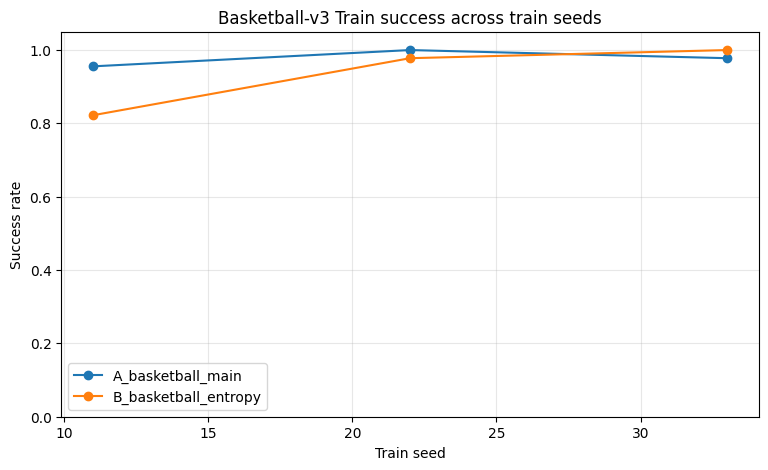

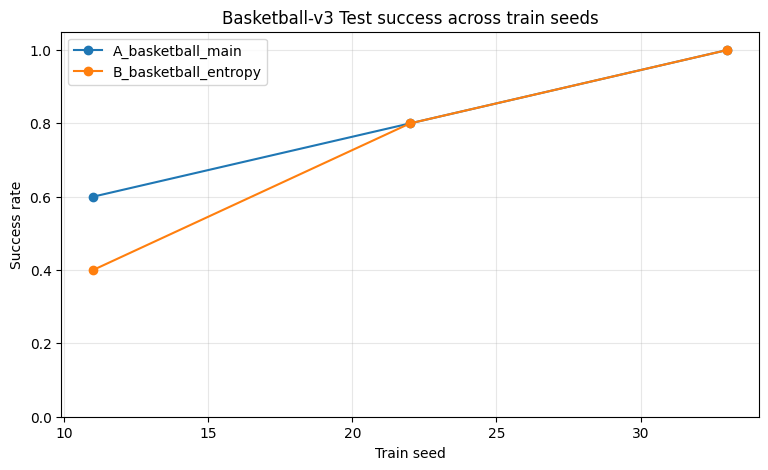

In [4]:
for metric, title in [
    ("train_mean_success", "Train success"),
    ("test_mean_success", "Test success"),
]:
    fig, ax = plt.subplots(figsize=(9, 5))
    for config in sorted(df["config_name"].unique()):
        d = df[df["config_name"] == config].sort_values("train_seed")
        ax.plot(d["train_seed"], d[metric], marker="o", label=config)
    ax.set_title(f"Basketball-v3 {title} across train seeds")
    ax.set_xlabel("Train seed")
    ax.set_ylabel("Success rate")
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()

## 4. Mean success across seeds

,config_name,train_success_mean,train_success_std,test_success_mean,test_success_std,train_return_mean,train_return_std,test_return_mean,test_return_std,success_gap_mean,success_gap_std,return_gap_mean,runs
0,A_basketball_main,0.977778,0.022222,0.800000,0.200000,4416.366359,45.359949,4093.679039,329.997439,0.177778,0.189867,322.687320,3
1,B_basketball_entropy,0.933333,0.096864,0.733333,0.305505,4363.585985,180.207171,4026.957314,425.444997,0.200000,0.211986,336.628671,3


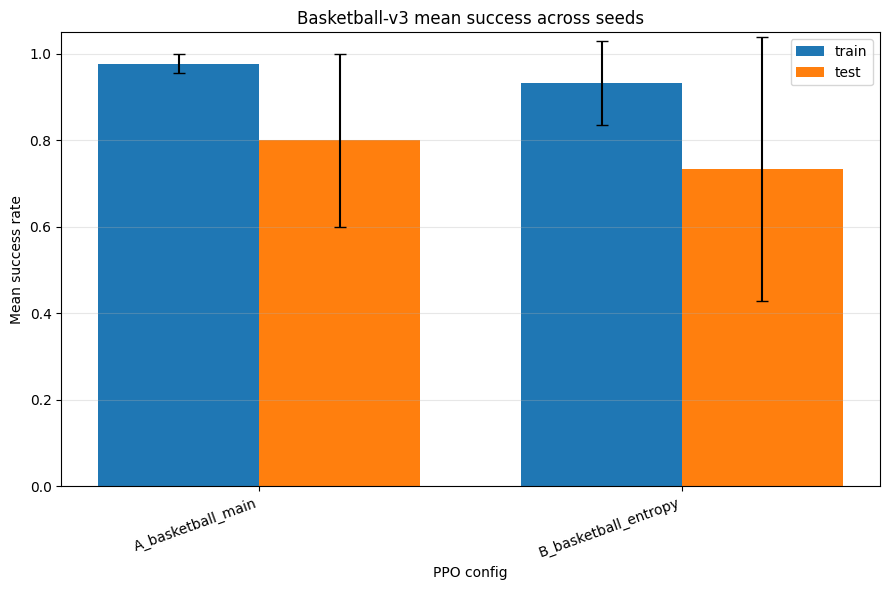

In [5]:
summary = (
    df.groupby("config_name")
    .agg(
        train_success_mean=("train_mean_success", "mean"),
        train_success_std=("train_mean_success", "std"),
        test_success_mean=("test_mean_success", "mean"),
        test_success_std=("test_mean_success", "std"),
        train_return_mean=("train_mean_return", "mean"),
        train_return_std=("train_mean_return", "std"),
        test_return_mean=("test_mean_return", "mean"),
        test_return_std=("test_mean_return", "std"),
        success_gap_mean=("success_gap", "mean"),
        success_gap_std=("success_gap", "std"),
        return_gap_mean=("return_gap", "mean"),
        runs=("train_seed", "count"),
    )
    .reset_index()
)

display(summary)

x = np.arange(len(summary))
width = 0.38
fig, ax = plt.subplots(figsize=(9, 6))
ax.bar(x - width/2, summary["train_success_mean"], width, yerr=summary["train_success_std"].fillna(0), capsize=4, label="train")
ax.bar(x + width/2, summary["test_success_mean"], width, yerr=summary["test_success_std"].fillna(0), capsize=4, label="test")
ax.set_title("Basketball-v3 mean success across seeds")
ax.set_xlabel("PPO config")
ax.set_ylabel("Mean success rate")
ax.set_ylim(0, 1.05)
ax.set_xticks(x)
ax.set_xticklabels(summary["config_name"], rotation=20, ha="right")
ax.grid(True, axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## Train-test success gap

`success_gap = train_mean_success - test_mean_success`.

Positive gap σημαίνει ότι το model τα πήγε καλύτερα στα train variations από ό,τι στα held-out test variations.

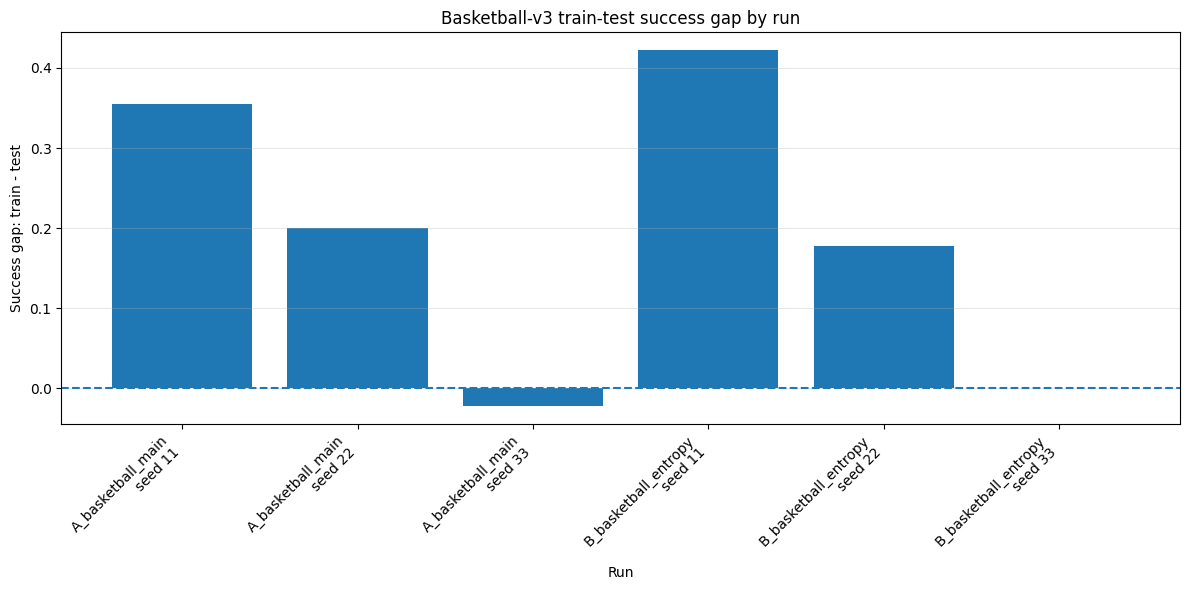

,config_name,train_seed,train_mean_success,test_mean_success,success_gap
0,A_basketball_main,11,0.955556,0.6,0.355556
1,A_basketball_main,22,1.000000,0.8,0.200000
2,A_basketball_main,33,0.977778,1.0,-0.022222
3,B_basketball_entropy,11,0.822222,0.4,0.422222
4,B_basketball_entropy,22,0.977778,0.8,0.177778
5,B_basketball_entropy,33,1.000000,1.0,0.000000


In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(plot_df))
labels = plot_df["config_name"] + "\nseed " + plot_df["train_seed"].astype(str)
ax.bar(x, plot_df["success_gap"])
ax.axhline(0, linestyle="--")
ax.set_title("Basketball-v3 train-test success gap by run")
ax.set_xlabel("Run")
ax.set_ylabel("Success gap: train - test")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

display(plot_df[["config_name", "train_seed", "train_mean_success", "test_mean_success", "success_gap"]])

## Return comparison

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(plot_df))
width = 0.38
ax.bar(x - width/2, plot_df["train_mean_return"], width, label="train")
ax.bar(x + width/2, plot_df["test_mean_return"], width, label="test")
ax.set_title("Basketball-v3 mean return by config and seed")
ax.set_xlabel("Run")
ax.set_ylabel("Mean return")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.grid(True, axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## Save figures

In [8]:
fig_dir = Path("basketball_figures")
fig_dir.mkdir(parents=True, exist_ok=True)

# Figure 1: train vs test success by run
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(plot_df))
width = 0.38
ax.bar(x - width/2, plot_df["train_mean_success"], width, label="train")
ax.bar(x + width/2, plot_df["test_mean_success"], width, label="test")
ax.set_title("Basketball-v3 PPO success rate by config and seed")
ax.set_xlabel("Run")
ax.set_ylabel("Success rate")
ax.set_ylim(0, 1.05)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.grid(True, axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
out1 = fig_dir / "basketball_success_by_config_seed.png"
fig.savefig(out1, dpi=200, bbox_inches="tight")
plt.close(fig)

# Figure 2: mean success across seeds
fig, ax = plt.subplots(figsize=(9, 6))
x = np.arange(len(summary))
ax.bar(x - width/2, summary["train_success_mean"], width, yerr=summary["train_success_std"].fillna(0), capsize=4, label="train")
ax.bar(x + width/2, summary["test_success_mean"], width, yerr=summary["test_success_std"].fillna(0), capsize=4, label="test")
ax.set_title("Basketball-v3 mean success across seeds")
ax.set_xlabel("PPO config")
ax.set_ylabel("Mean success rate")
ax.set_ylim(0, 1.05)
ax.set_xticks(x)
ax.set_xticklabels(summary["config_name"], rotation=20, ha="right")
ax.grid(True, axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
out2 = fig_dir / "basketball_mean_success_across_seeds.png"
fig.savefig(out2, dpi=200, bbox_inches="tight")
plt.close(fig)

# Figure 3: success gap
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(plot_df))
ax.bar(x, plot_df["success_gap"])
ax.axhline(0, linestyle="--")
ax.set_title("Basketball-v3 train-test success gap by run")
ax.set_xlabel("Run")
ax.set_ylabel("Success gap: train - test")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
out3 = fig_dir / "basketball_success_gap_by_run.png"
fig.savefig(out3, dpi=200, bbox_inches="tight")
plt.close(fig)

print("Saved figures:")
for p in [out1, out2, out3]:
    print(" -", p)

Saved figures:
 - basketball_figures\basketball_success_by_config_seed.png
 - basketball_figures\basketball_mean_success_across_seeds.png
 - basketball_figures\basketball_success_gap_by_run.png
